<a href="https://colab.research.google.com/github/ViniAndradeSan/Heart-Disease/blob/Vinicius/nootbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease
**Grupo 5:** Vinicius Andrade Santos e Marcelo de Jesus Menezes

**Fonte dos dados**: dataset Heart Disease, base Cleveland, do repositório UCI Machine Learning, acessado pelo pacote ucimlrepo.

**Atributo-alvo**: a variável num, que originalmente vai de 0 a 4 indicando ausência ou grau da doença. A gente binarizou: 0 continua sendo 'sem doença', e 1 a 4 vira 'com doença'.

**Atributos preditivos**: os 13 atributos clínicos da base; idade, sexo, tipo de dor no peito, pressão em repouso, colesterol, glicemia de jejum, resultado do eletrocardiograma em repouso, frequência cardíaca máxima, angina induzida por exercício, oldpeak, inclinação do segmento ST, número de vasos principais e talassemia.

Tipo da tarefa: classificação binária, já que o atributo-alvo representa categorias, com ou sem doença, e não um valor numérico contínuo."

**Objetivo:** Desenvolver um modelo capaz de ajudar pessoas responsaveis da saúde básica ou unidades de saúde com poucos profissionais,
              oferecendo uma estimativa inicial do risco de doença cardíaca.
---

## 1. Importação de Bibliotecas

In [ ]:
!pip install ucimlrepo -q

In [ ]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 2. Carregamento da Base

In [ ]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

In [ ]:
df = df.replace("?", pd.NA)

# 3. Descrição da Base

In [ ]:
df.shape

(303, 14)

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Interpretação

- A base de dados contém 303 registros válidos, distribuídos em 14 atributos clínicos.
- A maior parte das informações está armazenada como números inteiros.
- As variáveis oldpeak, ca e thal são registradas como números decimais.
(Isso está ocorrendo porque ca e thal têm alguns valores ausentes, então acaba que precisamos fazer isso, para que o panda possa lidar com esses casos.).

Os dados mostram que a idade média dos pacientes é de cerca de 54 anos, com idades variando de 29 a 77 anos, além disso, os níveis de colesterol variam bastante, indo de 126 a 564 mg/dL, ou seja, isso indica que a população tem perfis clínicos muito diferentes.

Ao verificar a qualidade dos dados, encontramos 4 valores ausentes na coluna ca e 2 na coluna thal, as outras variáveis estão completas, também confirmamos que não há registros duplicados, o que significa que não precisamos fazer limpezas adicionais nesse aspecto, o que resta agora é tratar os valores ausentes nas colunas ca e thal antes de treinar os modelos.

# 4. Análise Exploratória dos Dados (EDA)

## 4.1. Distribuição da variável

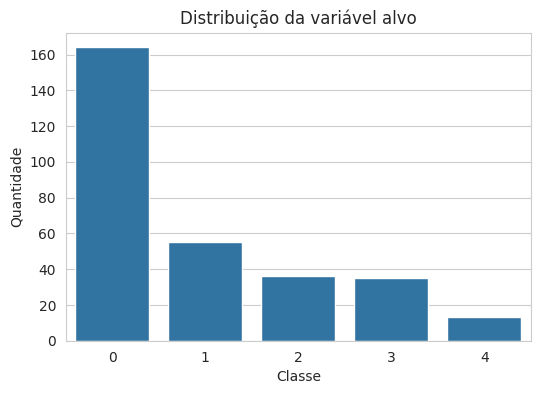

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='num')

plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

print(df['num'].value_counts())

## Interpretação

Analisando o gráfico da variável alvo (num), fica clara a diferença entre as categorias,a classe 0, de pessoas sem problemas cardíacos, concentra a maior parte da base: são 164 registros de um total de 303, o que dá cerca de 54% dos dados.
O restante se divide nos níveis da doença, somando 139 registros,desse grupo, a categoria 1 tem 55 exemplos, a 2 tem 36, a 3 tem 35 e a 4 tem apenas 13, essa distribuição vai impactar a construção dos modelos, se nós optarmos por uma classificação multiclasse, o algoritmo vai tender a acertar mais a classe 0 por ter mais volume, e deve ter dificuldade para identificar os níveis mais altos, principalmente o 3 e o 4, que têm poucos dados.

Mas, se transformar o problema em classificação binária (no caso, com ou sem doença), a base fica mais equilibradam mesmo assim, não vai dar para avaliar o modelo só pela acurácia. então, vamos precisar usar F1-score, recall e AUC. Também vamos anotar que talvez seja necessário aplicar SMOTE ou ajustar o peso das classes no algoritmo para o desequilíbrio não prejudicar o treinamento.

## 4.2. Histogramas

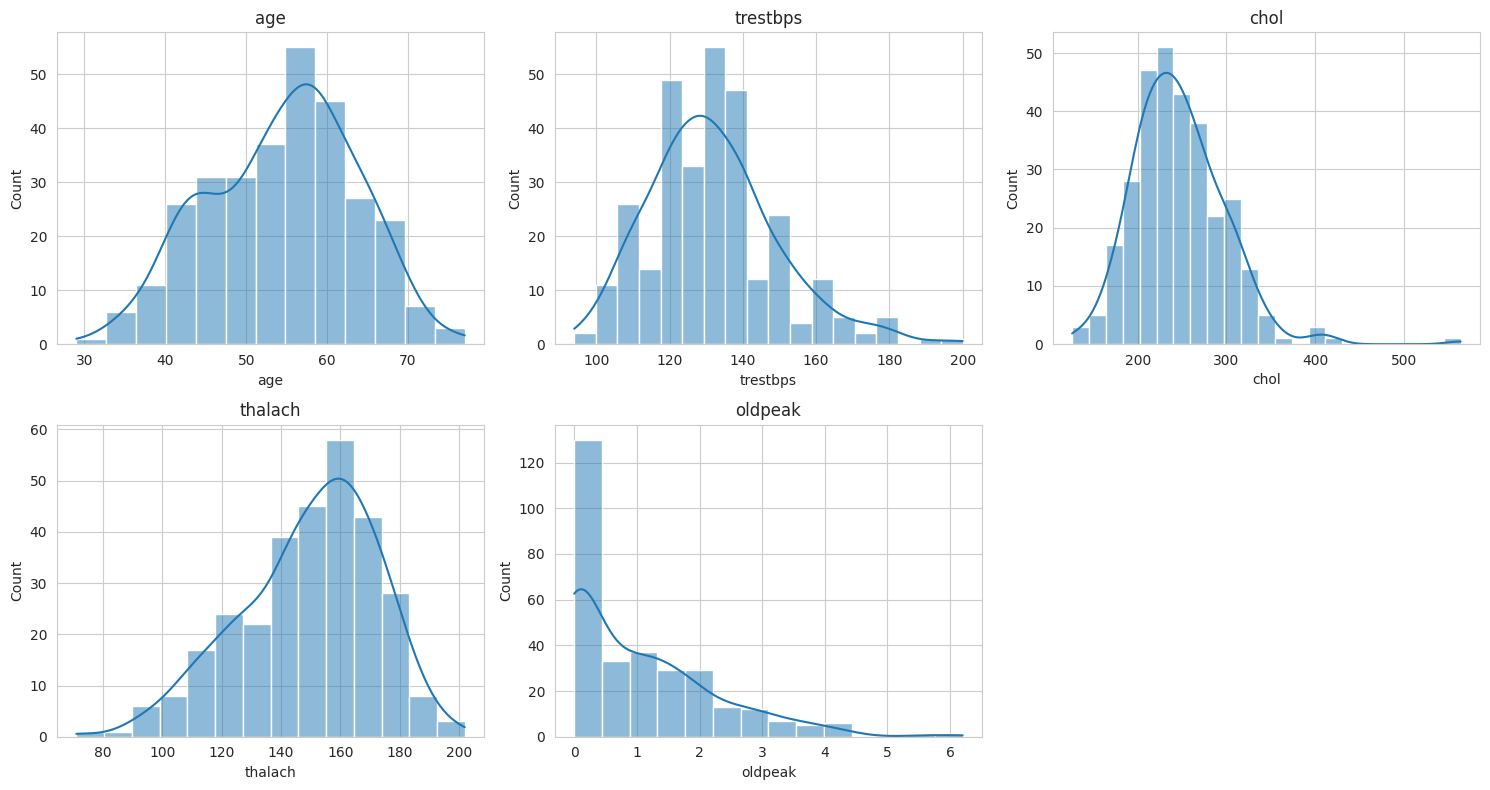

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

colunas = ['age','trestbps','chol','thalach','oldpeak']

for i, coluna in enumerate(colunas):
    sns.histplot(df[coluna], kde=True, ax=axes.flat[i])
    axes.flat[i].set_title(coluna)

axes.flat[-1].remove()

plt.tight_layout()
plt.show()

## Interpretação

Analisando os gráficos de distribuição, dá para notar algumas diferenças importantes entre as variáveis: A idade (age) tem um comportamento bem próximo de uma distribuição normal, concentrando a maioria dos pacientes entre 50 e 65 anos, já a pressão arterial em repouso (trestbps) mostra uma leve despropoção à direita, com a maior parte dos registros entre 120 e 140, mas com alguns valores perto de 200 que indicam possíveis outliers,
o colesterol (chol) segue uma linha parecida, só que com uma dispersão bem maior, o mais relevante dos dados fica entre 200 e 300, mas aparecem registros encostando em 500 que vamos precisar investigar se são casos reais extremos ou erros de preenchimento.

Enquanto isso, a frequência cardíaca máxima (thalach) veio mais equilibrada, concentrada entre 150 e 170.A maior discrepancia de todas ficou com a oldpeak, ela tem uma concentração massiva no valor 0 e alguns poucos registros que chegam perto de 6, puxando uma cauda longa para a direita, essas distorções e diferenças de comportamento afetam direto algoritmos sensíveis à escala dos dados, então temos que tomar cuidado. Por isso, já deixamos planejado no pré-processamento aplicar uma padronização (provavelmente o StandardScaler) e fazer o tratamento desses outliers, focando principalmente em chol, trestbps e oldpeak antes de abrir a fase de treino.

## 4.3. Boxplots

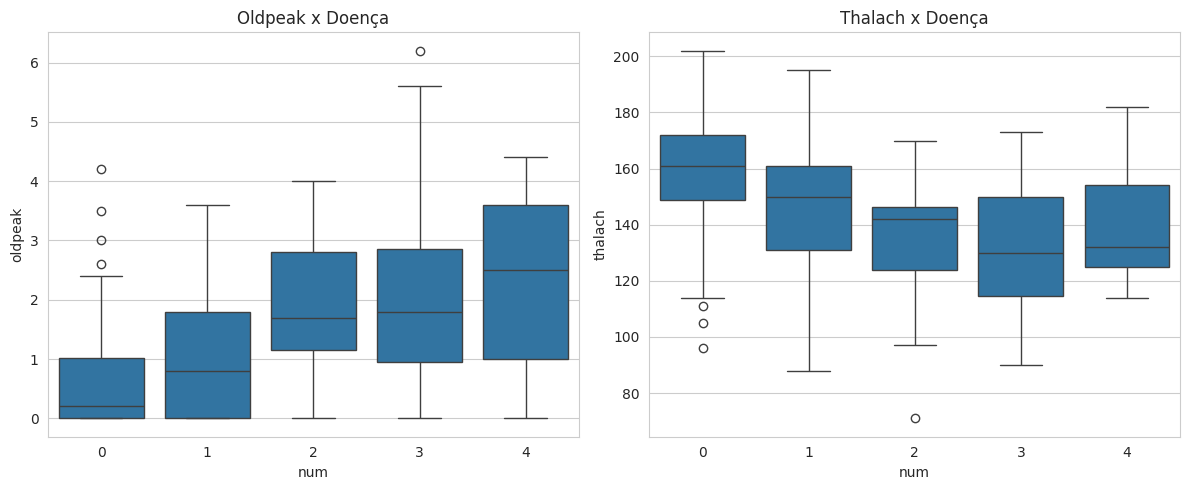

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df, x='num', y='oldpeak', ax=axes[0])
axes[0].set_title("Oldpeak x Doença")

sns.boxplot(data=df, x='num', y='thalach', ax=axes[1])
axes[1].set_title("Thalach x Doença")

plt.tight_layout()
plt.show()

## Interpretação

Analisando os boxplots, fica bem clara a relação dessas variáveis com as classes da doença, no caso de oldpeak, existe uma tendência nítida de aumento nos valores conforme a gravidade avança, a classe 0 tem a mediana colada no 0, enquanto a classe 4 joga os valores centrais ali entre 2.5 e 3, também deu para notar alguns outliers espalhados: tem paciente com valor acima de 4 na classe 0 e um registro encostando em 5.6 na classe 2.
Isso demostra que valores altos podem aparecer mesmo em quem não está nos estágios mais graves, para thalach, o comportamento é exatamente o oposto, a frequência cardíaca máxima vai caindo à medida que a classe da doença aumenta, A classe 0 começa com a mediana perto de 160, mas na classe 4 esse número despenca para a casa dos 130.

Esse padrão faz bastante sentido clínico, indicando que o comprometimento do coração limita a capacidade do paciente de atingir frequências mais altas no esforço.
No fim das contas, tanto oldpeak quanto thalach entregam um sinal forte e vão ajudar bastante os modelos a separarem as classes. O único cuidado que precisaremos ter antes do treino, é avaliar direito esses valores extremos, para entender se são apenas ruídos ou respostas reais e importantes para casos específicos.

## 4.4. Variáveis categóricas

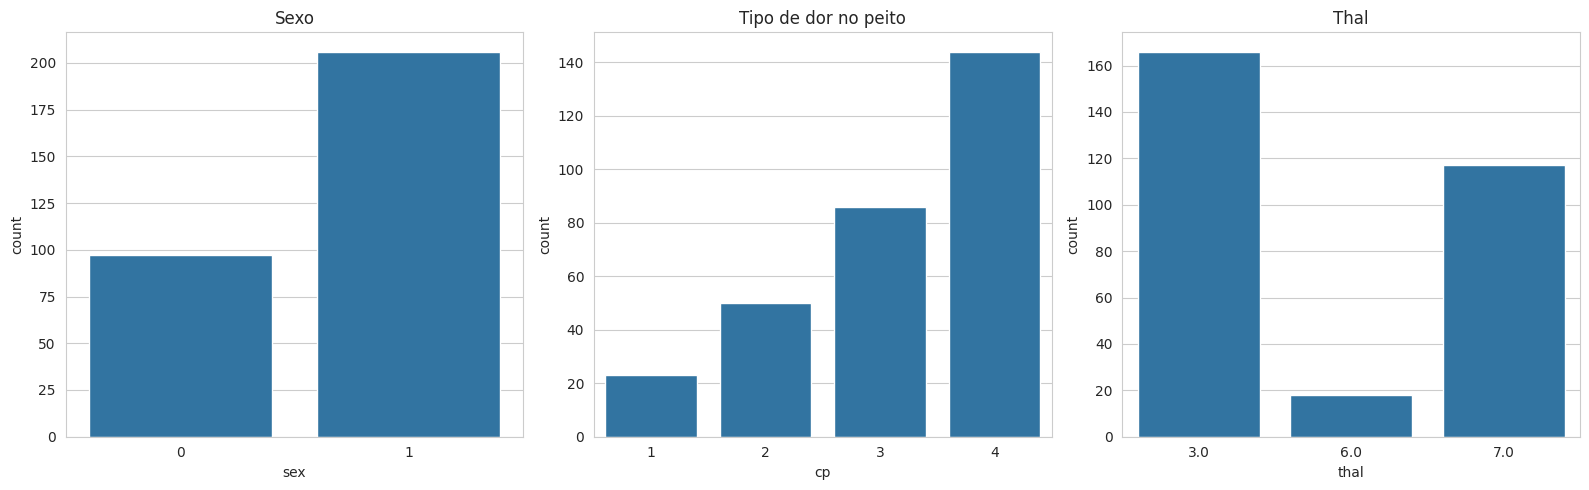

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

sns.countplot(data=df, x='sex', ax=axes[0])
axes[0].set_title("Sexo")

sns.countplot(data=df, x='cp', ax=axes[1])
axes[1].set_title("Tipo de dor no peito")

sns.countplot(data=df, x='thal', ax=axes[2])
axes[2].set_title("Thal")

plt.tight_layout()

plt.show()

In [ ]:
print(df['sex'].value_counts())
print()
print(df['cp'].value_counts())
print()
print(df['thal'].value_counts())

sex
1    206
0     97
Name: count, dtype: int64

cp
4    144
3     86
2     50
1     23
Name: count, dtype: int64

thal
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64


## Interpretação

Analisando a distribuição dessas variáveis categóricas, o desbalanceamento é evidente logo de cara, no caso de sexo, a diferença é bem grande: a categoria 1 tem por volta de 206 pacientes, enquanto a 0 tem cerca de 97, com os homens dominando a maior parte da amostra, precisamos ficar de olho se o modelo não vai perder desempenho na hora de prever o resultado para o grupo minoritário.

O tipo de dor no peito (cp) vai na mesma linha de distribuição desigual, os casos assintomáticos (categoria 4) lideram isolados com cerca de 145 pacientes. Depois vêm as categorias 3, 2 e 1, com aproximadamente 85, 50 e 20 registros, respectivamente, essa disparidade vai nos obriga a quando cruzar com as variaveis alvo, termos cuidado para entender como cada tipo de dor se comporta na hora de cravar a presença da doença.

A categoria 3.0 concentra a maior parte com uns 165 registros, a 7.0 vem atrás com cerca de 120, e a 6.0 fica quase isolada com apenas 20 casos. Pelo que pesquisamos, esse cenário de categorias muito vazias pode atrapalhar o algoritmo, principalmente depois que aplicar o one-hot encoding. vamos precisar monitorar a relevancia dessas classes menores para garantir que a transformação em variáveis dummy não acabe gerando ruído ou prejudicando a performance geral.

## 4.5. Correlação

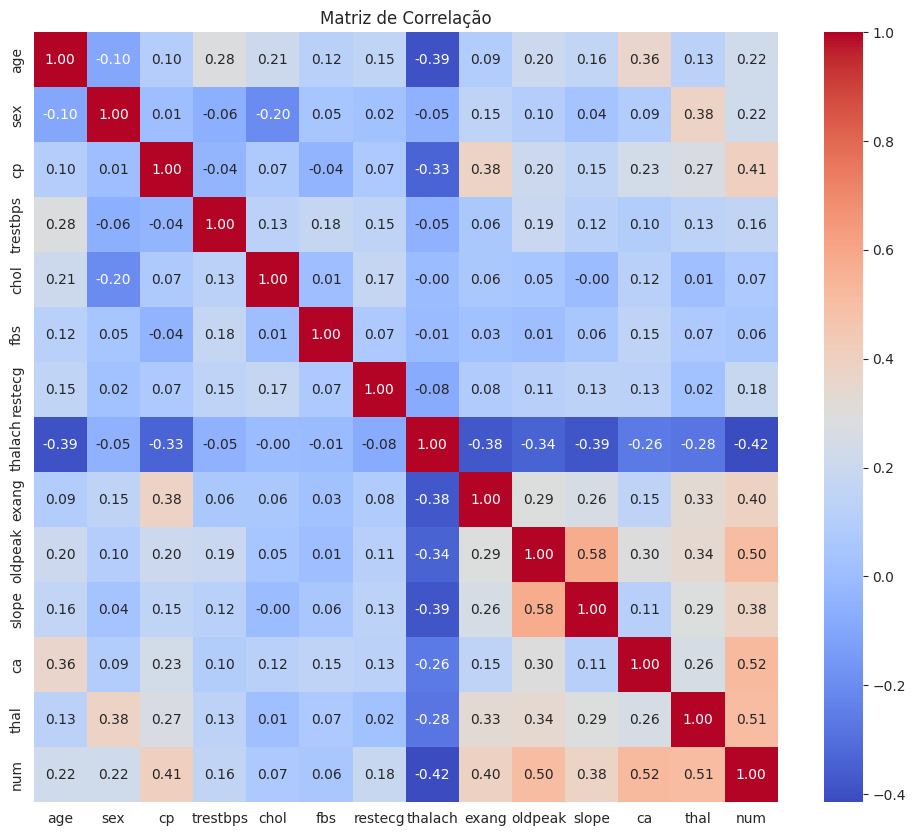

In [ ]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()

## Interpretação

Ao analisar a matriz de correlação com o alvo, os primeiros resultados relevantes foram ca (0.52), thal (0.51) e oldpeak (0.50), essas três variáveis mostram a relação linear mais forte com a presença da doença.
Em seguida, vem o segundo grupo importante: thalach (-0.42), cp (0.41) e exang (0.40), O valor negativo de thalach faz sentido com o que vimos antes nos boxplots, indicando que a frequência cardíaca máxima do paciente diminui conforme a doença avança, por outro lado, o comportamento de chol (0.07) e fbs (0.06) foi estranho, pelo que pesquisamos, segundo o MAIRINK, Carlos Henrique de almeida: "o colesterol e a glicemia de jejum são preditores clássicos de risco cardíaco", mas aqui na base eles não têm quase nenhuma correlação linear com o alvo.
Isso significa que, em modelos puramente lineares, essas variáveis não vão ajudar no resultado, apesar de serem clinicamente importantes.Também indetificamos uma colinearidade entre algumas características que vai exigir atenção na modelagem. A relação entre slope e oldpeak é de 0.58, e entre thal e sex é de 0.38.

Como pensamos em testar regressão logística depois, manter variáveis muito correlacionadas pode inflar os coeficientes e prejudicar as métricas do modelo.Por isso, anotamos que precisaremos aplicar alguma técnica de seleção de atributos antes de treinar os algoritmos, eliminando o excesso de dados repetidos.

---
## 5. Pré-processamento

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
df['target'] = (df['num'] > 0).astype(int)
X = df.drop(columns=['num', 'target'])
y = df['target']

In [ ]:
colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
colunas_categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino:\n{y_train.value_counts(normalize=True)}')
print(f'\nDistribuição no teste:\n{y_test.value_counts(normalize=True)}')

Treino: 242 amostras
Teste: 61 amostras

Distribuição no treino:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Distribuição no teste:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [ ]:
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', pipeline_numerico, colunas_numericas),
    ('cat', pipeline_categorico, colunas_categoricas)
])

## Justificativa

Para separar treino e teste, usamos "stratify=y", isso porque o alvo binário fica com uma proporção de aproximadamente 54% sem doença e 46% com doença, e sem a estratificação corríamos o risco de o split jogar mais casos de uma classe para o treino e desbalancear ainda mais o teste, os números confirmam que deu certo: a distribuição ficou praticamente idêntica entre treino (54,1%/45,9%) e teste (54,1%/45,9%).

Para as variáveis numéricas (age, trestbps, chol, thalach, oldpeak), aplicamos primeiro um "SimpleImputer" com a estratégia de mediana, e não a média, porque já vimos lá na EDA que chol e oldpeak têm outliers puxando a distribuição, então a mediana é mais robusta pra não sofrer o impacto desses valores extremos. Depois entra o "StandardScaler", que é essencial porque o SGDClassifier (que pretendemos testar) é sensível à escala, e as variáveis estão em unidades bem diferentes (idade em anos, colesterol em mg/dL, oldpeak em decimais pequenos).

Já para as categóricas (sex, cp, fbs, restecg, exang, slope, ca, thal), usamos o imputer com a estratégia de valor mais frequente, cobrindo os poucos ausentes de ca e thal que identificamos antes, e o OneHotEncoder com "drop='first'" para evitar multicolinearidade entre as dummies, além do "handle_unknown='ignore'" para o modelo não quebrar se aparecer alguma categoria rara do jeito que vimos em thal (a categoria 6.0, com só 18 casos) que não apareça em algum fold da validação cruzada.

Colocamos tudo dentro de um ColumnTransformer e depois de um Pipeline, justamente para garantir que o pré-processamento seja ajustado (fit) só nos dados de treino em cada fold da validação cruzada, evitando vazamento de dados (data leakage) entre treino e teste.

# 6. Modelagem

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
pipeline_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

scores_dummy = cross_val_score(pipeline_dummy, X_train, y_train, cv=5, scoring='accuracy')
print(f'DummyClassifier — Acurácia CV (5-fold): {scores_dummy.mean():.3f} ± {scores_dummy.std():.3f}')

DummyClassifier — Acurácia CV (5-fold): 0.541 ± 0.006


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
pipeline_sgd = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(max_iter=1000, random_state=42))
])

scores_sgd = cross_val_score(pipeline_sgd, X_train, y_train, cv=5, scoring='accuracy')
print(f'SGDClassifier — Acurácia CV (5-fold): {scores_sgd.mean():.3f} ± {scores_sgd.std():.3f}')

SGDClassifier — Acurácia CV (5-fold): 0.839 ± 0.048


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f'RandomForestClassifier — Acurácia CV (5-fold): {scores_rf.mean():.3f} ± {scores_rf.std():.3f}')

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


RandomForestClassifier — Acurácia CV (5-fold): 0.814 ± 0.066


## Interpretação

Testamos três modelos com validação cruzada de 5 folds, olhando a acurácia média: o DummyClassifier (que sempre chuta a classe mais frequente) ficou em 0,541 ± 0,006, esse é o nosso "piso", o valor que qualquer modelo de verdade precisa superar pra mostrar que está aprendendo algo além da proporção das classes.

O SGDClassifier surpreendeu e foi o que teve melhor desempenho, com 0,839 ± 0,048 de acurácia média, já o RandomForestClassifier ficou logo atrás, com 0,814 ± 0,066. Vale reparar que o desvio padrão do Random Forest foi bem maior que o do SGD, isso indica que o Random Forest teve mais instabilidade entre os folds, provavelmente porque a base é pequena (242 amostras de treino) e árvores tendem a ter mais variância nesse cenário, enquanto o SGD, por ser um modelo linear mais simples, generalizou de forma mais estável.

Isso bate com o que já tínhamos visto na análise de correlação: como ca, thal, oldpeak, thalach e cp têm relação linear forte com o alvo, faz sentido que um classificador linear como o SGD performe bem nessa base, sem precisar de toda a complexidade (e variância) de um ensemble de árvores. Por esse motivo, decidimos seguir com o SGDClassifier como o modelo final para avaliação no conjunto de teste.

# 7. Avaliação

In [ ]:
from sklearn.metrics import (
confusion_matrix, accuracy_score, precision_score,recall_score,
f1_score, classification_report, ConfusionMatrixDisplay)

In [ ]:
melhor_pipeline = pipeline_sgd
melhor_pipeline.fit(X_train, y_train)
y_pred = melhor_pipeline.predict(X_test)

In [ ]:
print('=== Métricas no Conjunto de Teste ===')
print(f'Acurácia:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precisão:  {precision_score(y_test, y_pred):.3f}')
print(f'Revocação: {recall_score(y_test, y_pred):.3f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Sem doença', 'Com doença']))

=== Métricas no Conjunto de Teste ===
Acurácia:  0.902
Precisão:  0.893
Revocação: 0.893
F1-Score:  0.893

              precision    recall  f1-score   support

  Sem doença       0.91      0.91      0.91        33
  Com doença       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



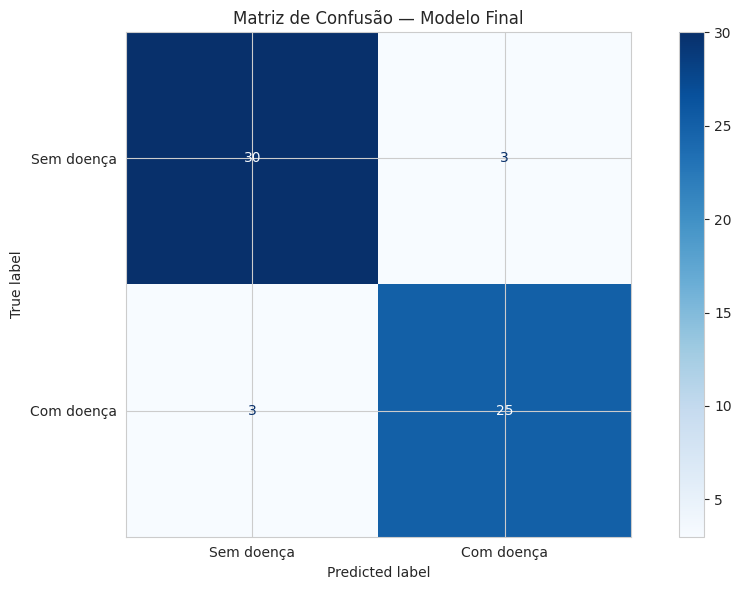

In [ ]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Sem doença', 'Com doença'], ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusão — Modelo Final')
plt.tight_layout()
plt.show()

## Interpretação
- 30 verdadeiros negativos: pacientes sem doença que o modelo acertou como sem doença.
- 25 verdadeiros positivos: pacientes com doença que o modelo acertou como com doença.
- 3 falsos positivos: sem doença, mas o modelo disse que tinha (erro "para mais").
- 3 falsos negativos: com doença, mas o modelo disse que não tinha (erro "para menos").

O modelo acertou 55 de 61 casos, batendo com a acurácia de 0,902 que a gente já tinha calculado.
Os erros ficaram beem simétricos, 3 pra cada lado, isso é bom porque mostra que o modelo não tá "enviesado" pra nenhuma classe, ele não tá, por exemplo, chutando "sem doença" só porque sim, e é mais fácil acertar essa classe.
Como FN e FP ficaram iguais (3 e 3), precisão e revocação também deram praticamente o mesmo valor (0,893 os dois), o que já esperávamos porque as classes no dataset estão relativamente balanceadas.

In [ ]:
resultados = {
    'Modelo': ['DummyClassifier', 'SGDClassifier', 'RandomForest'],
    'Acurácia CV (média)': [
        f'{scores_dummy.mean():.3f}',
        f'{scores_sgd.mean():.3f}',
        f'{scores_rf.mean():.3f}'
    ],
    'Acurácia CV (desvio)': [
        f'{scores_dummy.std():.3f}',
        f'{scores_sgd.std():.3f}',
        f'{scores_rf.std():.3f}'
    ]
}

pd.DataFrame(resultados)

,Modelo,Acurácia CV (média),Acurácia CV (desvio)
0,DummyClassifier,0.541,0.006
1,SGDClassifier,0.839,0.048
2,RandomForest,0.814,0.066


# Interpretação

No conjunto de teste, o modelo final (SGDClassifier) teve acurácia de 0,902, precisão de 0,893, revocação de 0,893 e F1-score de 0,893, esses números ficaram bem próximos entre si, o que é um bom sinal de que o modelo não está favorecendo uma classe às custas da outra.

Olhando o classification report, a classe "Sem doença" teve precisão e recall de 0,91, enquanto "Com doença" ficou em 0,89 nas duas métricas, ou seja, o modelo está praticamente equilibrado entre as duas classes, mesmo com o pequeno desbalanceamento original (54%/46%) que vimos lá na EDA. Isso indica que o pré-processamento (mediana + padronização + one-hot) e a escolha do SGD deram conta do desequilíbrio sem precisarmos recorrer a técnicas como SMOTE ou peso de classe, que tínhamos cogitado usar lá no início.

Vale notar que o resultado no teste (90,2%) ficou acima da média obtida na validação cruzada (83,9%), essa diferença pode ser só sorte do split de teste (61 amostras é uma base pequena, então a variância é esperada) ou pode ser um sinal de que precisamos rodar outras seeds/splits para confirmar se esse desempenho se mantém, isso é algo que vamos detalhar melhor na discussão.

# 8. Discussão

## Melhor modelo

O SGDClassifier foi o modelo escolhido, tanto na validação cruzada (0,839 ± 0,048) quanto no teste final (90,2% de acurácia) ele superou o RandomForest e, obviamente, o DummyClassifier. Isso reforça a leitura que fizemos na análise de correlação: como o problema tem várias variáveis com relação linear forte com o alvo (ca, thal, oldpeak, cp, thalach), um modelo linear simples consegue capturar bem o padrão sem sofrer com a variância que vimos no Random Forest.

## Onde o modelo erra

Pela matriz de confusão e pelo classification report, o modelo erra de forma bem parecida nas duas classes (recall de 0,91 para "sem doença" e 0,89 para "com doença"), sem um viés forte para nenhum lado. Ainda assim, esperamos que os erros se concentrem nos casos de fronteira, pacientes com valores intermediários de oldpeak e thalach (que, como vimos nos boxplots, se sobrepõem bastante entre as classes 0, 1 e 2), e principalmente nos casos que caem nas categorias mais raras, como thal = 6.0 (só 18 registros) ou nas classes 2, 3 e 4 de num, que já eram minoria antes mesmo de agruparmos em "com doença".

## Limitações do dataset

A base é pequena (303 registros, 242 no treino), o que já percebemos na alta variância entre folds, principalmente do Random Forest. Também temos valores ausentes em ca e thal, categorias bem desbalanceadas (como thal = 6.0, com apenas 18 casos, e cp = 1, com só 23), e um desbalanceamento moderado entre as classes do alvo original (num), que fica ainda mais acentuado quando olhamos os níveis 3 e 4 separadamente (35 e 13 casos). Além disso, é uma base de 1988, então os critérios clínicos e os hábitos da população podem não refletir perfeitamente o cenário atual.

## Melhorias possíveis

Testar outros algoritmos (como regressão logística com regularização L1/L2, já que identificamos colinearidade entre slope/oldpeak e thal/sex), aplicar seleção de atributos pra reduzir a redundância que vimos na matriz de correlação, ajustar hiperparâmetros via GridSearch/RandomSearch em vez de usar os valores default, e validar o modelo com outras seeds de split pra confirmar se a diferença entre a acurácia da validação cruzada (83,9%) e a do teste (90,2%) é consistente ou só uma variação do split. Também seria interessante coletar uma base mais recente e maior, pra reduzir a variância que vimos, principalmente nas classes menos representadas.

| Ferramenta | Finalidade | Parte do trabalho | Como foi verificado |
|------------|------------|-------------------|---------------------|
| Gemine | Ambiente de desenvolvimento e execução do notebook | estrutura e pesquisa de formatação basica dos textos, inclusive essa tabela | Visualziação esperada de texto e tabela |
| chatGPT | Analise de codigo e estrutura logica | Sessão 4 até a 7, focando em logica e melhoria para harmonia entre as bibliotecas | conferencia direta em relação a o que foi feito manual e o retorno esperado para fazer a analise coerente e precisa. |
| Claude | Apoio na escrita nas seções de justificativa/interpretação, mantendo o padrão de escrita do grupo, mas tendo e mantendo as ideias e interpretação originais | todas as sessões | comparaçaõ com nossa ideia origial, interpretação e pesquisa feita pelo grupo |